# OpenQARP — Official Tutorial 04: Your Own Variational Loop (Colab Edition)

This notebook is the **fifth official tutorial** from the OpenQARP repository
(`examples/tutorial_04_variational_loop.ipynb`), reproduced as-is from
https://github.com/OpenQARP/openqarp/tree/main/examples and wrapped with a
Colab install cell so it runs standalone, with nothing else changed.

This is where the four layers come together: a **VQE ground-state search for
a 3-qubit transverse-field Ising model**, first built **by hand** — ansatz +
primitive + engine + optimizer — and then reproduced with the package's
built-in `VQE` composite, to show it's exactly the same machinery underneath.

This is also the official reference for the `VQE` class's real constructor
signature (`operator=`, `ket=`, `initial_parameters=`, `optimizer=`,
`primitive=`, `engine=`) — worth comparing against any hand-rolled VQE loop
you've written before seeing this.

By Carlos Araque  
@KentryOps Data Labs  
Quantum researchers  
20-09-2026

## Setup (added for Colab — not part of the original tutorial)

Installs `openqarp` from PyPI, plus `matplotlib` for the convergence plot
later in this notebook (Colab ships both by default, but we pin them here for
reliability). Wheels ship for Linux/macOS/Windows on Python 3.11–3.14, so this
is a fast binary install, no compilation needed.

In [1]:
!pip install -q openqarp matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.0 MB/s eta 0:00:00


---

# Tutorial 04 — Your own variational loop (and the one you get for free)

Time to assemble the layers. We'll find the ground state of a 3-qubit
transverse-field Ising model

$$H = -\sum_{i} Z_i Z_{i+1} - h \sum_i X_i, \qquad h = 0.5$$

first **by hand** — ansatz + primitive + engine + optimizer — and then with the
built-in `VQE` composite, so you can see it's the same machinery.

In [2]:
import numpy as np
from qarp.operators import QubitOperator

n = 3
h = 0.5
H = QubitOperator()
for i in range(n - 1):
    H += QubitOperator(f"Z{i} Z{i+1}", -1.0)
for i in range(n):
    H += QubitOperator(f"X{i}", -h)

# Exact reference from the dense matrix (qarpx LSB, like everything else).
exact = np.linalg.eigvalsh(H.sparse_matrix().toarray())[0]
print("exact ground energy:", exact)

exact ground energy: -2.4032119259115534


## 1. The four ingredients

In [3]:
from qarp.blocks import HEABlock
from qarp.algorithms import StateVector
from qarp.engines import QarpEngine
from qarp.optimizers import ScipyOptimizer

ansatz = HEABlock(n, 2, True, True, True, False).build()
expval = StateVector(bra=ansatz, operator=H, ket=ansatz)

engine = QarpEngine()
engine.build([expval])           # compile once, before the loop

symbols = ansatz.symbols
print(len(symbols), "parameters")

6 parameters


## 2. The objective function

An objective is just: zip the parameter vector onto the (name-sorted!) symbol
list, run the engine, take the scalar.

In [4]:
evals = []

def energy(x):
    E = engine.run(dict(zip(symbols, x)))[0].real
    evals.append(E)
    return E

## 3. Minimise

In [5]:
rng = np.random.default_rng(42)
x0 = rng.uniform(0, 2 * np.pi, len(symbols))

opt = ScipyOptimizer("COBYLA", options={"maxiter": 400})
result = opt.minimize(energy, x0)

print(f"VQE energy:   {result.fun:.6f}")
print(f"exact energy: {exact:.6f}")
print(f"error:        {result.fun - exact:.2e}   ({len(evals)} evaluations)")

VQE energy:   -2.403212
exact energy: -2.403212
error:        1.87e-09   (240 evaluations)


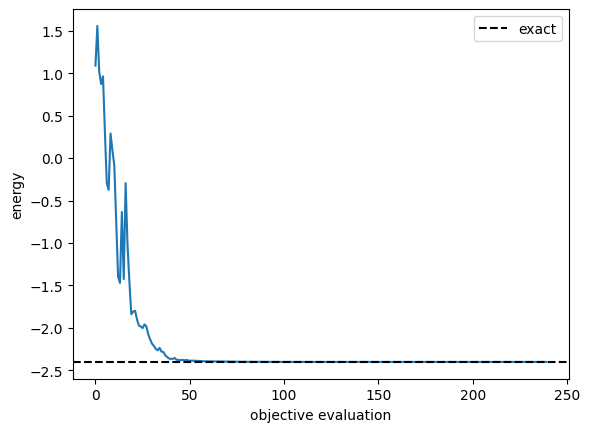

In [6]:
import matplotlib.pyplot as plt

plt.plot(evals)
plt.axhline(exact, ls="--", c="k", label="exact")
plt.xlabel("objective evaluation")
plt.ylabel("energy")
plt.legend();

## 4. With gradients

`engine.run_gradient` (tutorial 03) plugs straight into gradient-based
optimizers:

In [7]:
def gradient(x):
    return engine.run_gradient(dict(zip(symbols, x)))[0]

result_cg = ScipyOptimizer("CG").minimize(energy, x0, gradient=gradient)
print(f"CG energy:    {result_cg.fun:.6f}   error {result_cg.fun - exact:.2e}")

CG energy:    -2.403212   error 3.65e-11


## 5. The reveal: this *is* `VQE`

The `VQE` composite wires up exactly the objects you just wired — it owns the
primitive, engine, optimizer and loop, and exposes the same knobs as
constructor arguments:

In [8]:
from qarp.algorithms import VQE

vqe = VQE(
    operator=H,
    ket=HEABlock(n, 2, True, True, True, False).build(),
    initial_parameters=x0,
    optimizer=ScipyOptimizer("COBYLA", options={"maxiter": 400}),
    primitive=StateVector(),
    engine=QarpEngine(),
    verbose=False,
)
vqe.build()
e, p = vqe.run()
print(f"VQE composite: {e:.6f}   error {e - exact:.2e}")

VQE minimization finished successfully
VQE composite: -2.403212   error 1.87e-09


Swap the `primitive=` for `TermwiseHadamardTest(n_shots=...)` and the same
algorithm runs shot-based; swap the `engine=` for a noisy device engine and it
runs noisy. That orthogonality — algorithm x primitive x engine — is the core
design of the package.

## Poke at it

* `vqe.result` (the full scipy `OptimizeResult`), `vqe.history`
* re-run the hand-rolled loop with `TermwiseHadamardTest` instead of
  `StateVector` and a seeded engine: shot noise meets COBYLA
* try `gradient=True` in the `VQE` constructor

**Next:** tutorial_05_algorithm_tour — what's in the composite-algorithm
toolbox, and which MWE notebook to open for each.

---

*Source: [OpenQARP/openqarp, examples/tutorial_04_variational_loop.ipynb](https://github.com/OpenQARP/openqarp/tree/main/examples), Apache License 2.0, Fujitsu Research of Europe.*